<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/conspiraciones/llms-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Funcionalidades de LLMs

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html). Consiste en una colección de textos extraidos de Telegram anotados manualmente como mensajes "críticos" (`CRITICAL`) frente a "conspirativos" (`CONSPIRACY`).

En el siguiente código, utilizamos la biblioteca [Hugging Face](https://huggingface.co/) para realizar diversas tareas con modelos de lenguaje. En particular, aprovecharemos las utilidades de [`transformers`](https://huggingface.co/docs/transformers/index) para usar modelos de lenguaje.

Parte del código está basado en los ejemplos del libro:

> [**Hands-On Large Language Models**](https://www.oreilly.com/library/view/hands-on-large-language/9781098150969/)  
by Jay Alammar, Maarten Grootendorst  
Released September 2024  
Publisher(s): O'Reilly Media, Inc.  
ISBN: 9781098150969

Y en los tutoriales de [Hugging Face](https://huggingface.co/).

Se recomienda usar el _backend_ de TPU para ejecutar este ejemplo en Google Colab gratuito.


## Carga de datos

In [1]:
import pandas as pd

data = pd.read_csv('dataset.csv')
data

,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


## Generación de texto
Para generar texto, debemos cargar un modelo capaz de generar texto, como por ejemplo [`microsoft/Phi-3.5-mini-instruct`](https://huggingface.co/microsoft/Phi-3.5-mini-instruct). Además, necesitamos crear un _tokenizador_ apropiado. Para ello, podemos usar las `auto clases` de HuggingFace, como se explica en [este tutorial](https://huggingface.co/docs/transformers/llm_tutorial).

Podríamos utilizar otros modelos más reducidos, aunque los resultados puede que no sean adecuados. Por ejemplo, [`deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5`](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B).

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/Phi-3.5-mini-instruct"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.3k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/3.98k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

A continuación, creamos un [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) para generación de texto, usando el tipo `text-generation`. (El tipo de [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) debe ser uno soportado por el modelo de lenguaje especificado.)

In [3]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

Device set to use cuda:0


Ya podemos enviar mensajes al [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline), que los pasará al modelo cargado en el formato adecuado y obtendremos la salida correspondiente.

In [4]:
# Prompt
messages = [
  {"role": "user",
   "content": "What is a surplus in business?"}
]

# Obtener salida
response = pipe(messages)
print(response)

# Extraer campo de interés
print(response[0]["generated_text"])

[{'generated_text': ' A surplus in business refers to an excess of supply over demand for a particular product or service at a given price level. This situation typically occurs when the quantity of goods or services produced by a company exceeds the quantity that consumers are willing and able to purchase at the current market price.\n\nHere are some key points about surplus in business:\n\n1. Price and demand relationship: Surplus often occurs when prices are set too high, leading to a decrease in demand. Conversely, if prices are too low, it may not cover production costs, leading to a surplus.\n\n2. Inventory management: Surplus can result from poor inventory management, where a company overestimates demand and produces or stocks more than necessary.\n\n3. Market conditions: Changes in market conditions, such as shifts in consumer preferences, economic downturns, or increased competition, can lead to a surplus.\n\n4. Business strategies: Some businesses intentionally create a surpl

## Conversaciones
Siguiendo una aproximación parecida, podemos interactuar con el agente/modelo en [modo conversación](https://huggingface.co/docs/transformers/conversations). Realmente, la única diferencia es que vamos almacenando la historia del chat (consultas y respuestas) y pasándosela por completo en cada interacción, en el orden recibido y especificando los contenidos (`content`) y roles (`role`) de cada interacción.

In [5]:
# Recuperar chat anterior
chat = [
    {"role": "user","content": "What is a surplus in business?"},  # Petición 1
    {"role": "assistant", "content": response[0]["generated_text"]} # Respuesta 1
]

# Añadir nueva interacción
chat.append({"role": "user", "content": "Why don't you explain this to me like I am an eight-year old?"} # Petición 2
)

# Obtener y mostrar salida
response = pipe(chat)
print(response[0]["generated_text"])

 Of course! Imagine you have a lemonade stand. You make a big pitcher of lemonade because you think everyone in your neighborhood will want to buy it. But when you open your stand, not everyone comes to buy your lemonade. You have more lemonade left over than people want to drink. This extra lemonade is like a "surplus" in business.

Here's a simple way to understand it:

1. Making too much lemonade: You thought everyone would want to buy your lemonade, but they didn't. You made more than what people wanted to buy.

2. Too many lemonades left: Because you made more than people wanted, you have extra lemonades that nobody is drinking.

3. Not enough customers: This happens when you think more people will come to buy your lemonade, but fewer people actually show up.

4. What to do with extra lemonade: You might lower the price to make it more tempting for people to buy, or you could try to find new friends who might want to drink your lemonade.

In business, when a company makes more of 

In [6]:
# Añadir nueva interacción
chat.append({"role": "assistant", "content": response[0]["generated_text"]}) # Respuesta 2
chat.append({"role": "user", "content": "Why don't you explain this to me like I'm five?"}) # Petición 3

# Obtener y mostrar salida
response = pipe(chat)
print(response[0]["generated_text"])

 Absolutely! Let's imagine you have a box of crayons. You think you have enough crayons for all your friends to color with, but when they come over, they don't want to use any crayons. You have extra crayons that nobody is using. This extra crayons are like a "surplus" in business.

Here's a simple way to understand it:

1. Too many crayons: You thought all your friends would want to color, but they didn't. You have more crayons than your friends need.

2. Extra crayons left: Because you have more crayons than your friends want, you have extra crayons that nobody is using.

3. Not enough friends to color: This happens when you think more friends will come to color, but fewer friends actually show up.

4. What to do with extra crayons: You might share them with other kids who want to color, or you could save them for another time when more friends come over.

In business, when a company makes more of something than people want to buy, it's called a "surplus." It's like having extra cray

## Análisis de sentimientos
Para esta tarea, primero creamos un [`pipeline`](https://huggingface.co/docs/transformers/v4.49.0/en/main_classes/pipelines#transformers.pipeline) de análisis de sentimientos y cargamos el modelo [`cardiffnlp/twitter-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment).

Este modelo nos ayuda a determinar el sentimiento de un texto, clasificándolo como positivo, negativo o neutral (LABEL_0 -> Negative; LABEL_1 -> Neutral; LABEL_2 -> Positive). Disponemos de multitud de modelos alternativos en el repositorio de [Hugging Face](https://huggingface.co/); por ejemplo, para [análisis de sentimientos en español](https://huggingface.co/models?language=es&other=sentiment-analysis&sort=trending).

In [7]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


La función `analyze_sentiment()` toma una frase como entrada y utiliza el pipeline para obtener la etiqueta de sentimiento y su puntuación de confianza, que devuelve como salida.

In [8]:
def analyze_sentiment(pipe, sentence):
    try:
        response = pipe(sentence)[0]
        return response['label'], response['score']
    except Exception as e:
        print(f"Error analizando el sentimiento para '{sentence}': {e}")
        return "UNKNOWN", 0.0

Finalmente, aplicamos la función `analyze_sentiment()` a cada texto en la columna `text` de nuestro conjunto de datos, almacenando los resultados en un nuevo `DataFrame`. Si un texto es demasiado largo, se trunca a 512 caracteres para evitar errores de procesamiento.

In [9]:
from tqdm import tqdm

sentiment_labels = []
sentiment_scores = []

for text in tqdm(data['text'], desc="Processing Sentiments"):
    truncated_text = text[:512] if len(text) > 512 else text
    sentiment_label, sentiment_score = analyze_sentiment(sentiment_pipe, truncated_text)
    sentiment_labels.append(sentiment_label)
    sentiment_scores.append(sentiment_score)

data_sentiment = pd.DataFrame({
    'text': data['text'],
    'category': data['category'],
    'sentiment_label': [label.replace('LABEL_0', 'Negative').replace('LABEL_1', 'Neutral').replace('LABEL_2', 'Positive') for label in sentiment_labels],
    'sentiment_score': sentiment_scores
})

data_sentiment


Processing Sentiments:   0%|          | 4/4000 [00:00<01:41, 39.23it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

Processing Sentiments: 100%|██████████| 4000/4000 [00:38<00:00, 103.04it/s]


,text,category,sentiment_label,sentiment_score
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,Negative,0.609890
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,Negative,0.791545
2,2021 : They wanted to know your vaccination st...,CRITICAL,Negative,0.659615
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,Neutral,0.511057
4,Proof has emerged showing that death from Wuha...,CRITICAL,Negative,0.484783
...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL,Negative,0.865195
3996,I personally do n’t believe Putin would set of...,CONSPIRACY,Negative,0.528019
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL,Neutral,0.509923
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL,Negative,0.583312


Podemos observar la distribución de valores de sentimiento en el conjunto de datos.

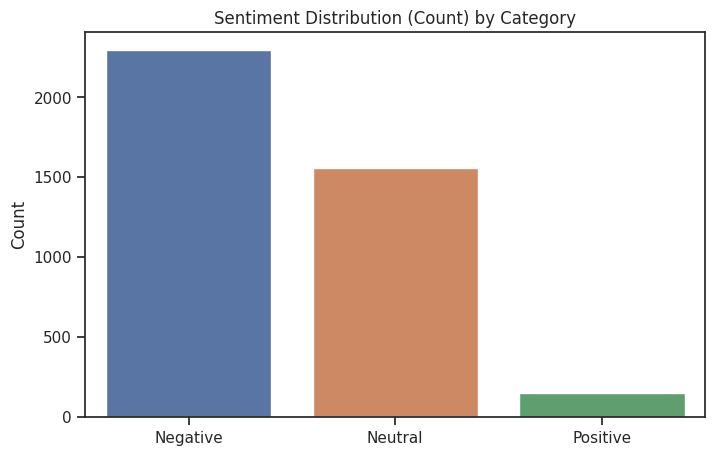

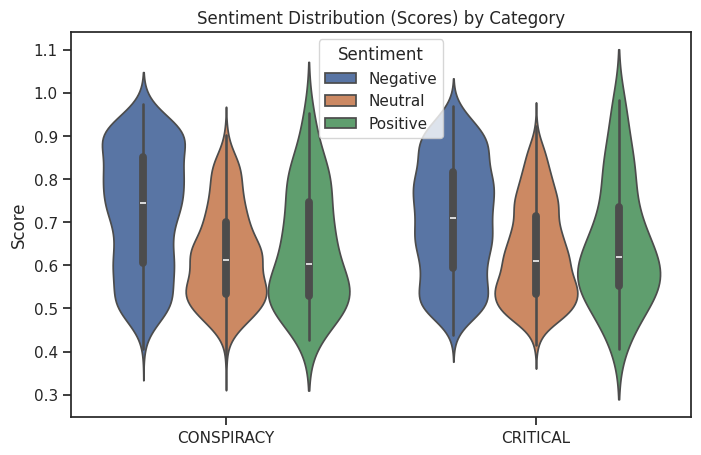

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.countplot(data=data_sentiment, x='sentiment_label', hue='sentiment_label', order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Distribution (Count) by Category')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.violinplot(data=data_sentiment, x='category', y='sentiment_score', hue='sentiment_label')
plt.title('Sentiment Distribution (Scores) by Category')
plt.xlabel('')
plt.ylabel('Score')
plt.legend(title='Sentiment')
plt.show()


## Reconocimiento de entidades
El reconocimiento de entidades con nombre (NER, por sus siglas en inglés) es una tarea de clasificación de _tokens_ que busca identificar y clasificar entidades mencionadas en un texto en categorías predefinidas, como personas, organizaciones, ubicaciones, etc. En este caso, utilizaremos el modelo [`bert-base-NER`](https://huggingface.co/dslim/bert-base-NER), que está optimizado para estas tareas.

(Existen otras tareas de clasificación de _tokens_, ver [aquí](https://huggingface.co/docs/transformers/task_summary#token-classification).)

In [11]:
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Utilizamos el `pipeline` anterior para extraer entidades del primer mensaje del conjunto de datos.

In [12]:
text = data['text'].values[0]
response = ner_pipeline(text)
preds = [
    {
        "entity": prediction["entity"],
        "score": round(prediction["score"], 4),
        "index": prediction["index"],
        "word": prediction["word"],
        "start": prediction["start"],
        "end": prediction["end"],
    }
    for prediction in response
]
print(text)
print(pd.DataFrame(preds))

THIS IS MASSIVE Australian Senator Malcolm Roberts exposes nanotech found in the Covid ‘ vaccines ’ and says they are genocide . He is the first politician to expose this !   SHARE https :// t . me / LauraAbolichannel 
   entity   score  index        word  start  end
0  B-MISC  0.9838      8  Australian     16   26
1   B-PER  0.9997     10     Malcolm     35   42
2   I-PER  0.9996     11     Roberts     43   50
3  B-MISC  0.9917     20          Co     81   83
4  I-MISC  0.8605     21       ##vid     83   86
5   I-PER  0.3427     53         ##A    205  206


## Clasificación con LLMs

Ahora, utilizaremos el modelo de lenguaje de OpenAI, ChatGPT, para clasificar textos en dos categorías: `CONSPIRACY` o `CRITICAL`. Para acceder a este modelo, se utiliza la biblioteca [`openai`](https://platform.openai.com/docs/guides/text-generation), que se conecta a la API remota de OpenAI (**de pago**). El procedimiento es el siguiente:

- Primero, se solicita al usuario que introduzca su clave de API de OpenAI para autenticar las solicitudes al servicio y se inicia el cliente.
- Después, se define una función llamada `classify_text_with_chatgpt` que toma un texto como entrada y utiliza el modelo de lenguaje para clasificarlo. La función envía una solicitud al modelo con un prompt que le pide clasificar el texto en una de las dos categorías.
- Si la clasificación es exitosa, se devuelve la categoría; de lo contrario, se maneja cualquier excepción y se devuelve `UNKNOWN`. Finalmente, se aplica esta función a cada texto en la columna 'text' de los datos, almacenando los resultados en un nuevo DataFrame llamado `data_classification`.

In [13]:
from openai import OpenAI
import getpass

# Solicitar la clave de API de OpenAI al usuario
my_api_key = getpass.getpass("Por favor, introduce tu clave de API de OpenAI: ")

# Inicializar cliente
client = OpenAI(api_key=my_api_key)

# Función para clasificar texto utilizando ChatGPT
def classify_text_with_chatgpt(text):
    try:
        response = client.chat.completions.create(
            model="gpt-4",
            messages=[{
                "role": "developer",
                "content": f"Classify the following text as CONSPIRACY or CRITICAL: {text}. "}]
        )
        classification = response.choices[0].message.content.strip()
        return classification
    except Exception as e:
        print(f"Error while classifying the text '{text}': {e}")
        return "UNKNOWN"

# Aplicar clasificación a cada texto en la columna 'text'
# (limitado a los `limit` primeros mensajes)
classifications = []
limit = 25

for text in tqdm(data['text'][:limit], desc="Classifying texts"):
    classification = classify_text_with_chatgpt(text)
    classifications.append(classification)

# Crear DataFrame con los resultados
data_classification = pd.DataFrame({
    'text': data['text'][:limit],
    'real_category': data['category'][:limit],
    'llm_classification': classifications
})

data_classification

Por favor, introduce tu clave de API de OpenAI: ··········


Classifying texts: 100%|██████████| 25/25 [00:15<00:00,  1.62it/s]


,text,real_category,llm_classification
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL,CONSPIRACY
3,Anthony Fauci once again defended brutal Chine...,CRITICAL,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL,CONSPIRACY
5,"Joe Biden , who told Americans last year , “ Y...",CRITICAL,CONSPIRACY
6,""" 1861 for a number of black - magick - relate...",CONSPIRACY,CONSPIRACY
7,WHAT THE HELL HAVE THEY DONE ? FOREIGN PARTICL...,CRITICAL,CONSPIRACY
8,Joe Biden ’s Commerce Secretary has claimed th...,CRITICAL,CRITICAL
9,""" COVID : ALLEGED DOCUMENT PREDICTING THE FREN...",CRITICAL,CONSPIRACY


Sobre estas predicciones, se pueden calcular las métricas habituales.

              precision    recall  f1-score   support

  CONSPIRACY       0.53      1.00      0.69        10
    CRITICAL       1.00      0.40      0.57        15

    accuracy                           0.64        25
   macro avg       0.76      0.70      0.63        25
weighted avg       0.81      0.64      0.62        25



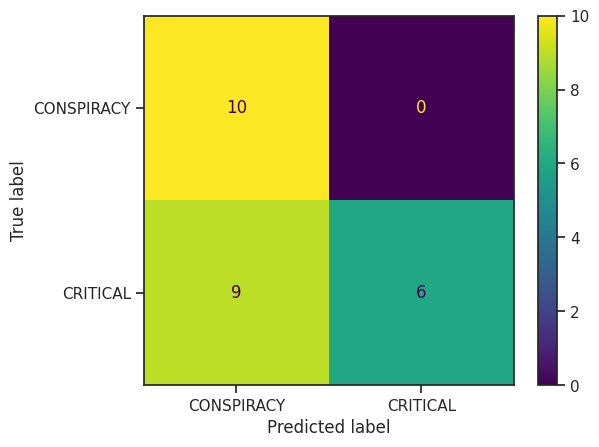

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(
    data_classification['real_category'],
    data_classification['llm_classification']))

cm = confusion_matrix(
    data_classification['real_category'],
    data_classification['llm_classification'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CONSPIRACY', 'CRITICAL'])
disp.plot()

## Modelado de temas
Para _topic modeling_, podemos utilizar la biblioteca [`BERTopic`](https://maartengr.github.io/BERTopic/index.html), que implementa las siguientes etapas:

- Codificación de _tokens_
- Reducción de dimensionalidad
- Agrupamiento en temas
- Descripción de temas

En primer lugar, necesitamos instalar [`BERTopic`](https://maartengr.github.io/BERTopic/index.html). Puede que Colab sugiera reiniciar el entorno, pero no es conveniente hacerlo.

In [15]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

A continuación, tomamos la lista de textos sobre la que queremos extraer los temas, creamos el modelo de _topics_ con [`BERTopic()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic) y lo ajustamos a estos textos con [`fit()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.fit).

Adicionalmente, se puede incluir preprocesamiento específico, como por ejemplo eliminación de palabras sin significado (_stop words_), a través de [`CountVectorizer()`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) de [`scikit-learn`](https://scikit-learn.org/stable/index.html).

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

docs = data['text'].tolist()

topic_model = BERTopic(
    vectorizer_model=CountVectorizer(stop_words="english"),
    language="english",
    calculate_probabilities=True)

topics, probabilities = topic_model.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[`BERTopic`](https://maartengr.github.io/BERTopic/index.html) incluye numerosas utilidades para analizar los resultados de la extracción. Los más interesantes son la lista de _topics_ y la lista de mensajes con su _topic_ asociado.

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info

In [ ]:
document_info = topic_model.get_document_info(docs)
document_info

Podemos combinar los resultados de la extracción con la información disponible; por ejemplo, las etiquetas de clasificación de cada texto.

In [ ]:
document_info['category'] = data['category']
document_info

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,-1,-1_covid_vaccine_https_people,"[covid, vaccine, https, people, nt, 19, new, c...",[“ A public official acting in contravention o...,covid - vaccine - https - people - nt - 19 - n...,0.976021,False,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,2,2_children_fda_kids_schedule,"[children, fda, kids, schedule, child, childho...",[America Is Now the Only Country in the World ...,children - fda - kids - schedule - child - chi...,1.000000,False,CRITICAL
2,2021 : They wanted to know your vaccination st...,-1,-1_covid_vaccine_https_people,"[covid, vaccine, https, people, nt, 19, new, c...",[“ A public official acting in contravention o...,covid - vaccine - https - people - nt - 19 - n...,0.774908,False,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,12,12_fauci_rand_anthony_paul,"[fauci, rand, anthony, paul, summit, desantis,...",[[ FAUCI ] covered up of HIV being a BIOWEAPON...,fauci - rand - anthony - paul - summit - desan...,1.000000,False,CRITICAL
4,Proof has emerged showing that death from Wuha...,-1,-1_covid_vaccine_https_people,"[covid, vaccine, https, people, nt, 19, new, c...",[“ A public official acting in contravention o...,covid - vaccine - https - people - nt - 19 - n...,0.698157,False,CRITICAL
...,...,...,...,...,...,...,...,...,...
3995,Police in Australia are warning that unvaccina...,24,24_australia_australians_nsw_unvaccinated,"[australia, australians, nsw, unvaccinated, au...",[Covid - 19 Deaths are rising sharply in Austr...,australia - australians - nsw - unvaccinated -...,1.000000,False,CRITICAL
3996,I personally do n’t believe Putin would set of...,1,1_ukraine_russia_putin_russian,"[ukraine, russia, putin, russian, ukrainian, w...",[The conflict unfolding in Ukraine is deeply t...,ukraine - russia - putin - russian - ukrainian...,1.000000,False,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,0,0_pfizer_trial_fda_data,"[pfizer, trial, fda, data, documents, moderna,...","[PFIZER DOCUMENTS Pfizer has dropped 10,000 do...",pfizer - trial - fda - data - documents - mode...,0.366165,False,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",-1,-1_covid_vaccine_https_people,"[covid, vaccine, https, people, nt, 19, new, c...",[“ A public official acting in contravention o...,covid - vaccine - https - people - nt - 19 - n...,0.903146,False,CRITICAL


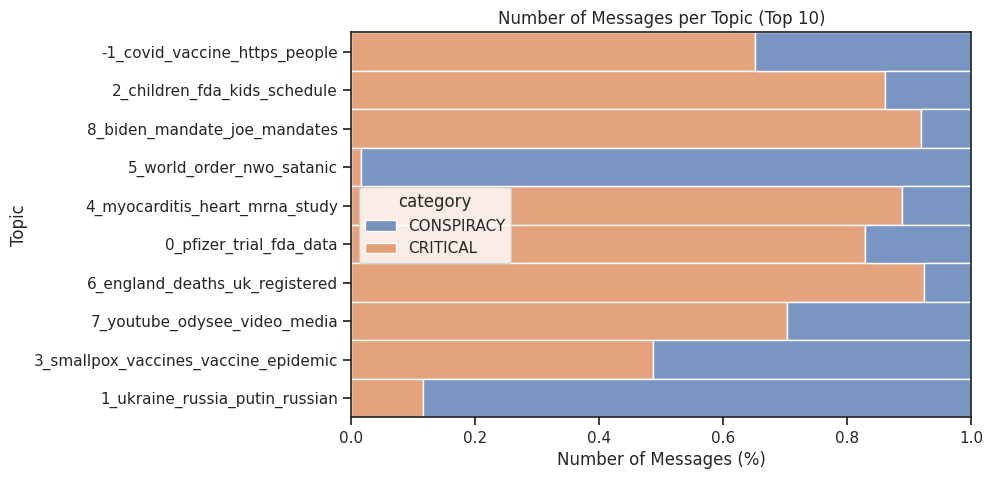

In [ ]:
# Limitar a los primeros 10 temas
top_10_topics = topic_info['Topic'][:10].tolist()
document_info_top_10 = document_info[document_info['Topic'].isin(top_10_topics)]

# Crear gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.histplot(data=document_info_top_10, y='Name', hue='category', multiple="fill", discrete=True)
plt.title('Number of Messages per Topic (Top 10)')
plt.ylabel('Topic')
plt.xlabel('Number of Messages (%)')
plt.show()

Otras visualizaciones interesantes son, por ejemplo:

- La ubicación de los _topics_ en un plano 2D [`visualize_topics()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_topics)
- Los términos más relevantes de cada _topic_ [`visualize_barchart()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_barchart)
- La jerarquía considerando la granularidad de los _topics [`visualize_hierarchy()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.visualize_hierarchy)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_hierarchy()

Existen métodos alternativos para la obtención de las representaciones de los _topics_. Una de ellas es recurrir a un agente conversacional para que nos dé una posible descripción de cada _topic_.

A continuación, se muestra un ejemplo con ChatGPT. Para ello, es necesario configurar el modelo de representación que usará [`BERTopic`](https://maartengr.github.io/BERTopic/index.html) como un modelo [`OpenAI`](https://maartengr.github.io/BERTopic/api/representation/openai.html) y especificar la clave de conexión a la API. Adicionalmente, es necesario usar el _tokenizador_ correcto, para lo cual puede utilizarse [`tiktoken`](https://github.com/openai/tiktoken).

In [ ]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.6 MB/s eta 0:00:00


In [ ]:
import tiktoken
from bertopic.representation import OpenAI
import openai

def configure_representation_model_OpenAI(api_key: str, model: str = "gpt-4o-mini"):
    # Tokenizer
    tokenizer= tiktoken.encoding_for_model(model)

    # Modelo de representación
    client = openai.OpenAI(api_key=api_key)
    representation_model = OpenAI(
        client,
        model=model,
        delay_in_seconds=2,
        chat=True,
        nr_docs=25,
        doc_length=100,
        tokenizer=tokenizer
    )

    return representation_model

Una vez configurado, el modelo [`BERTopic()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic) con representación obtenida con ChatGPT se crea de forma análoga a la anterior y se entrena con [`fit()`](https://maartengr.github.io/BERTopic/api/bertopic.html#bertopic._bertopic.BERTopic.fit).

In [ ]:
from bertopic.representation import KeyBERTInspired

representation_model = {
    "Representation KeyBERT":    KeyBERTInspired(),
    "Representation OpenAI":     configure_representation_model_OpenAI(my_api_key)
}

topic_model = BERTopic(
    representation_model=representation_model,
    vectorizer_model=CountVectorizer(stop_words="english"),
    language="english",
    calculate_probabilities=True)

topics, probabilities = topic_model.fit_transform(docs)

topic_model.get_topic_info()